## Importación de librerías
Esta sección se dedica a la importación de las bibliotecas de Python esenciales para el desarrollo del taller. Cada librería cumple una función específica en la captura, simulación y visualización de datos.

- matplotlib.pyplot: Módulo fundamental de Matplotlib para la creación de gráficos estáticos y dinámicos.
- matplotlib.animation: Proporciona las herramientas necesarias para la animación de gráficos, permitiendo la visualización de datos en tiempo real.
- numpy: Biblioteca para computación numérica de alto rendimiento, utilizada para la generación de datos simulados (ej., funciones sinusoidales y ruido aleatorio).
- plotly.graph_objects: Componente de Plotly para la construcción de figuras y gráficos interactivos.
- collections.deque: Una implementación de cola de doble extremo, utilizada aquí como un búfer eficiente para almacenar un número limitado de los datos más recientes.
- pandas: Biblioteca para manipulación y análisis de datos, empleada para la exportación de datos a formatos como CSV al final del proceso.
- datetime: Módulo para trabajar con fechas y horas, utilizado para generar marcas de tiempo precisas para los datos.

In [16]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import plotly.graph_objects as go
from collections import deque
import pandas as pd
import datetime

## Visualización de Temperatura en Tiempo Real con Matplotlib
Este bloque implementa la visualización de datos en tiempo real utilizando Matplotlib, simulando una métrica de temperatura que se actualiza continuamente en un gráfico de líneas.

1. Configuración Inicial: Se definen los parámetros para la simulación, incluyendo la capacidad máxima del búfer (max_points). Se inicializan los objetos deque para data_buffer (temperatura) y time_buffer (tiempo), que almacenarán los puntos de datos. Se configura la figura y los ejes del gráfico, estableciendo el título, las etiquetas de los ejes y el rango inicial del eje Y.
2. Función de Actualización (update): Esta función es el núcleo de la animación. Es invocada periódicamente por FuncAnimation:
- Genera un nuevo valor de temperatura utilizando una combinación de una función sinusoidal y ruido aleatorio para simular variaciones realistas.
- Agrega el nuevo dato de temperatura y su correspondiente valor de tiempo al final de los deque.
- Actualiza los datos de la línea en el gráfico y ajusta dinámicamente los límites del eje X para asegurar que los datos más recientes sean siempre visibles.
- Imprime el tiempo y la temperatura actuales en la consola, proporcionando una vista textual de los datos generados.
3. Animación (FuncAnimation): La función animation.FuncAnimation coordina la ejecución de la función update en intervalos regulares (en este caso, cada 500 milisegundos), creando una animación fluida del gráfico.

/tmp/ipython-input-17-1550487131.py:31: UserWarning:

frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.

/tmp/ipython-input-17-1550487131.py:24: UserWarning:

Attempting to set identical low and high xlims makes transformation singular; automatically expanding.



Tiempo: 0.50, Temperatura: 22.70°C
Tiempo: 1.00, Temperatura: 23.59°C


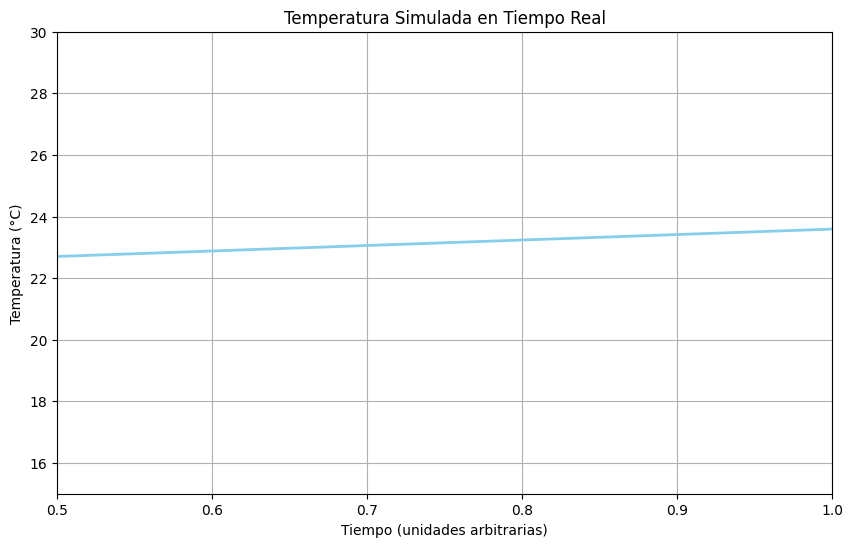

In [ ]:
max_points = 100
data_buffer = deque(maxlen=max_points)
time_buffer = deque(maxlen=max_points)
start_time = 0

fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot([], [], lw=2, color='skyblue')
ax.set_title("Temperatura Simulada en Tiempo Real")
ax.set_xlabel("Tiempo (unidades arbitrarias)")
ax.set_ylabel("Temperatura (°C)")
ax.set_ylim(15, 30)
ax.grid(True)

def update(frame):
    global start_time
    new_time = start_time + 0.5
    temperature = 22 + 5 * np.sin(new_time / 5) + np.random.randn() * 0.5 

    data_buffer.append(temperature)
    time_buffer.append(new_time)

    line.set_data(list(time_buffer), list(data_buffer))

    ax.set_xlim(min(time_buffer) if time_buffer else 0, max(time_buffer) if time_buffer else 1)

    print(f"Tiempo: {new_time:.2f}, Temperatura: {temperature:.2f}°C") 

    start_time = new_time
    return line,

ani = animation.FuncAnimation(fig, update, interval=500, blit=True) 

plt.show()

## Visualización de Conteo de Objetos con Plotly (Actualización Segmentada)
Este bloque demuestra la visualización de datos de conteo de objetos utilizando Plotly. Dada la naturaleza de los cuadernos de Colab, la actualización en "tiempo real" con Plotly en este contexto se simula mediante la ejecución repetida de la celda, lo que genera y renderiza un nuevo estado del gráfico en cada ejecución.

1. Generación de Datos: La función generate_new_plotly_data() (previamente definida en el código completo) se encarga de crear un nuevo punto de conteo de objetos con su marca de tiempo actual. Este punto se añade a los búferes (count_data y timestamp_data).
2. Actualización del Gráfico: Las líneas que actualizan fig_plotly.data[0].x y fig_plotly.data[0].y toman los datos completos y actualizados de los deque y los asignan a las propiedades del gráfico de Plotly. Esto le indica a Plotly que debe redibujar la serie con los nuevos valores.
3. Renderizado (fig_plotly.show()): Esta función renderiza el gráfico interactivo de Plotly con el estado actual de los datos.

In [18]:
max_points_plotly = 50
count_data = deque(maxlen=max_points_plotly)
timestamp_data = deque(maxlen=max_points_plotly)

fig_plotly = go.Figure(
    data=[go.Scatter(x=list(timestamp_data), y=list(count_data), mode='lines+markers')],
    layout=go.Layout(
        title='Conteo de Objetos en Tiempo Real',
        xaxis=dict(title='Tiempo'),
        yaxis=dict(title='Conteo', range=[0, 20]),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Iniciar/Actualizar Simulación",
                          method="animate",
                          args=[None, {"frame": {"duration": 500, "redraw": True}, "fromcurrent": True, "transition": {"duration": 300, "easing": "quadratic-in-out"}}])
            ]
        )]
    )
)

def generate_new_plotly_data():
    current_time = datetime.datetime.now().strftime("%H:%M:%S")
    if not count_data:
        new_count = np.random.randint(5, 15)
    else:
        last_count = count_data[-1]
        change = np.random.randint(-2, 3)
        new_count = max(0, last_count + change)

    count_data.append(new_count)
    timestamp_data.append(current_time)

    print(f"Tiempo: {current_time}, Conteo: {new_count}") # Mostrar en consola

for _ in range(10):
    generate_new_plotly_data()

print("\n--- Plotly - Conteo de Objetos (Ejecutar esta celda varias veces para ver la actualización) ---")
generate_new_plotly_data() # Genera un nuevo punto cada vez que ejecutas esta celda
fig_plotly.data[0].x = list(timestamp_data)
fig_plotly.data[0].y = list(count_data)
fig_plotly.show()

Tiempo: 06:16:43, Conteo: 14
Tiempo: 06:16:43, Conteo: 13
Tiempo: 06:16:43, Conteo: 15
Tiempo: 06:16:43, Conteo: 13
Tiempo: 06:16:43, Conteo: 14
Tiempo: 06:16:43, Conteo: 14
Tiempo: 06:16:43, Conteo: 12
Tiempo: 06:16:43, Conteo: 12
Tiempo: 06:16:43, Conteo: 11
Tiempo: 06:16:43, Conteo: 12

--- Plotly - Conteo de Objetos (Ejecutar esta celda varias veces para ver la actualización) ---
Tiempo: 06:16:43, Conteo: 14


## Exportación de Datos y Estadísticas
Este bloque final se encarga de procesar y guardar los datos recolectados durante las simulaciones, así como de generar un resumen estadístico y exportar el gráfico de Matplotlib.

1. Exportación a CSV:
- Se crea un objeto DataFrame de Pandas utilizando los datos de tiempo y temperatura almacenados en los deque de la simulación de Matplotlib.
- Este DataFrame se guarda en un archivo .csv llamado temperatura_simulada.csv. El parámetro index=False asegura que el índice de Pandas no se incluya en el archivo de salida. Esto es fundamental para tener un registro persistente de los datos simulados.
2. Cálculo y Presentación de Estadísticas:
- Se calculan y muestran estadísticas clave para la temperatura (promedio, máximo y mínimo) a partir de data_buffer. Estas métricas ofrecen una visión rápida del comportamiento general de la temperatura simulada.
- De manera similar, se presentan estadísticas para el conteo de objetos (promedio, máximo y mínimo) si los datos correspondientes (count_data) están disponibles de la sección de Plotly. Esta parte es condicional, ya que la simulación de Plotly se ejecuta de forma segmentada.
3. Exportación de Gráfico como Imagen:
- Finalmente, se guarda la figura generada por Matplotlib (fig) como un archivo de imagen .png (temperatura_simulada.png). Esto permite tener una representación visual estática del último estado del gráfico animado.

In [19]:
print("\n--- Exportando datos de temperatura a CSV ---")
df_temp = pd.DataFrame({
    'Time': list(time_buffer),
    'Temperature': list(data_buffer)
})
df_temp.to_csv('temperatura_simulada.csv', index=False)
print("Datos de temperatura exportados a 'temperatura_simulada.csv'")

print("\n--- Estadísticas de Temperatura ---")
if data_buffer:
    print(f"Temperatura Promedio: {np.mean(list(data_buffer)):.2f}°C")
    print(f"Temperatura Máxima: {np.max(list(data_buffer)):.2f}°C")
    print(f"Temperatura Mínima: {np.min(list(data_buffer)):.2f}°C")
else:
    print("No hay datos de temperatura para calcular estadísticas.")

print("\n--- Estadísticas de Conteo (si ejecutaste la sección de Plotly) ---")
if count_data:
    print(f"Conteo Promedio: {np.mean(list(count_data)):.2f}")
    print(f"Conteo Máximo: {np.max(list(count_data)):.2f}")
    print(f"Conteo Mínimo: {np.min(list(count_data)):.2f}")
else:
    print("No hay datos de conteo para calcular estadísticas.")

print("\n--- Exportando gráfico de Matplotlib como PNG ---")
fig.savefig('temperatura_simulada.png')
print("Gráfico de temperatura exportado a 'temperatura_simulada.png'")


--- Exportando datos de temperatura a CSV ---
Datos de temperatura exportados a 'temperatura_simulada.csv'

--- Estadísticas de Temperatura ---
Temperatura Promedio: 23.15°C
Temperatura Máxima: 23.59°C
Temperatura Mínima: 22.70°C

--- Estadísticas de Conteo (si ejecutaste la sección de Plotly) ---
Conteo Promedio: 13.09
Conteo Máximo: 15.00
Conteo Mínimo: 11.00

--- Exportando gráfico de Matplotlib como PNG ---
Gráfico de temperatura exportado a 'temperatura_simulada.png'
